# Classification Model Using Scikit-learn

## 1. Introduction
In this notebook, I explore the Titanic dataset and build a binary classification model to predict passenger survival.

The notebook is structured as follows:

1. Load and inspect the dataset
2. Create summary statistics and visualizations
3. Define features and target
4. Train a logistic regression model with scikit-learn
5. Evaluate the model using classification metrics

## 2. Load dataset

In [66]:
import pandas as pd

data = pd.read_csv("../data/titanic.csv")
data.head()  #check the first 5 lines

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


## 3. Exploration
### 3.1 Inspect dataset

In [67]:
data.columns  #to get all features

Index(['sex', 'age', 'family_size', 'fare', '1st_class', '2nd_class',
       '3rd_class', 'survived'],
      dtype='str')

In [68]:
data.shape  #check the size of the data

(887, 8)

In [69]:
data.info()  #check missing values

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB


### 3.2 Data summaries

In [70]:
data.describe() #statistical data

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
count,887.000000,887.000000,887.000000,887.00000,887.000000,887.000000,887.000000,887.000000
mean,0.645998,29.471443,0.908681,32.30542,0.243517,0.207441,0.549042,0.385569
std,0.478480,14.121908,1.615949,49.78204,0.429447,0.405703,0.497870,0.487004
min,0.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.250000,0.000000,7.92500,0.000000,0.000000,0.000000,0.000000
50%,1.000000,28.000000,0.000000,14.45420,0.000000,0.000000,1.000000,0.000000
75%,1.000000,38.000000,1.000000,31.13750,0.000000,0.000000,1.000000,1.000000
max,1.000000,80.000000,10.000000,512.32920,1.000000,1.000000,1.000000,1.000000


In [71]:
data["survived"].value_counts() #show number of each target class.

survived
0    545
1    342
Name: count, dtype: int64

In [72]:
data["survived"].value_counts(normalize=True) #show percentage of each target class.

survived
0    0.614431
1    0.385569
Name: proportion, dtype: float64

#### Observation
1. No missing values;
2. About 38.6% of passengers survived. The target classes are not perfectly balanced.
3. The average passenger age is about 29.5 years, and the median age is 28 years.
4. Most passengers paid relatively low fares, but a few passengers paid much higher fares.
5. Around 54.9% of passengers are in third class.

## 4. EDA/Visualizations

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

### 4.1 Target distribution

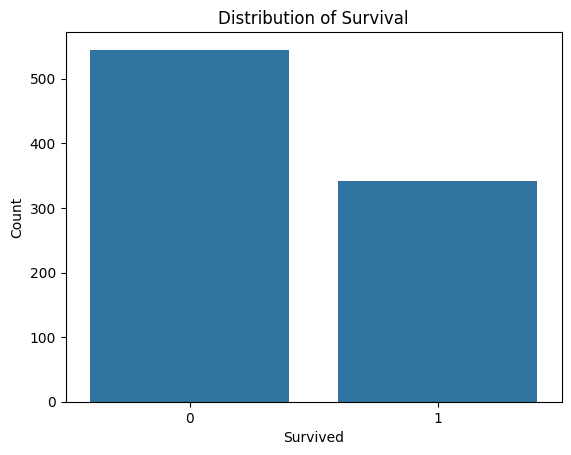

In [74]:
sns.countplot(data=data, x="survived")  
plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

The count plot helps check whether the two classes are balanced or imbalanced.
It shows that more passengers did not survive than survived. Therefore, accuracy alone may not be enough to evaluate the model later.

### 4.2 Single feature vs survival

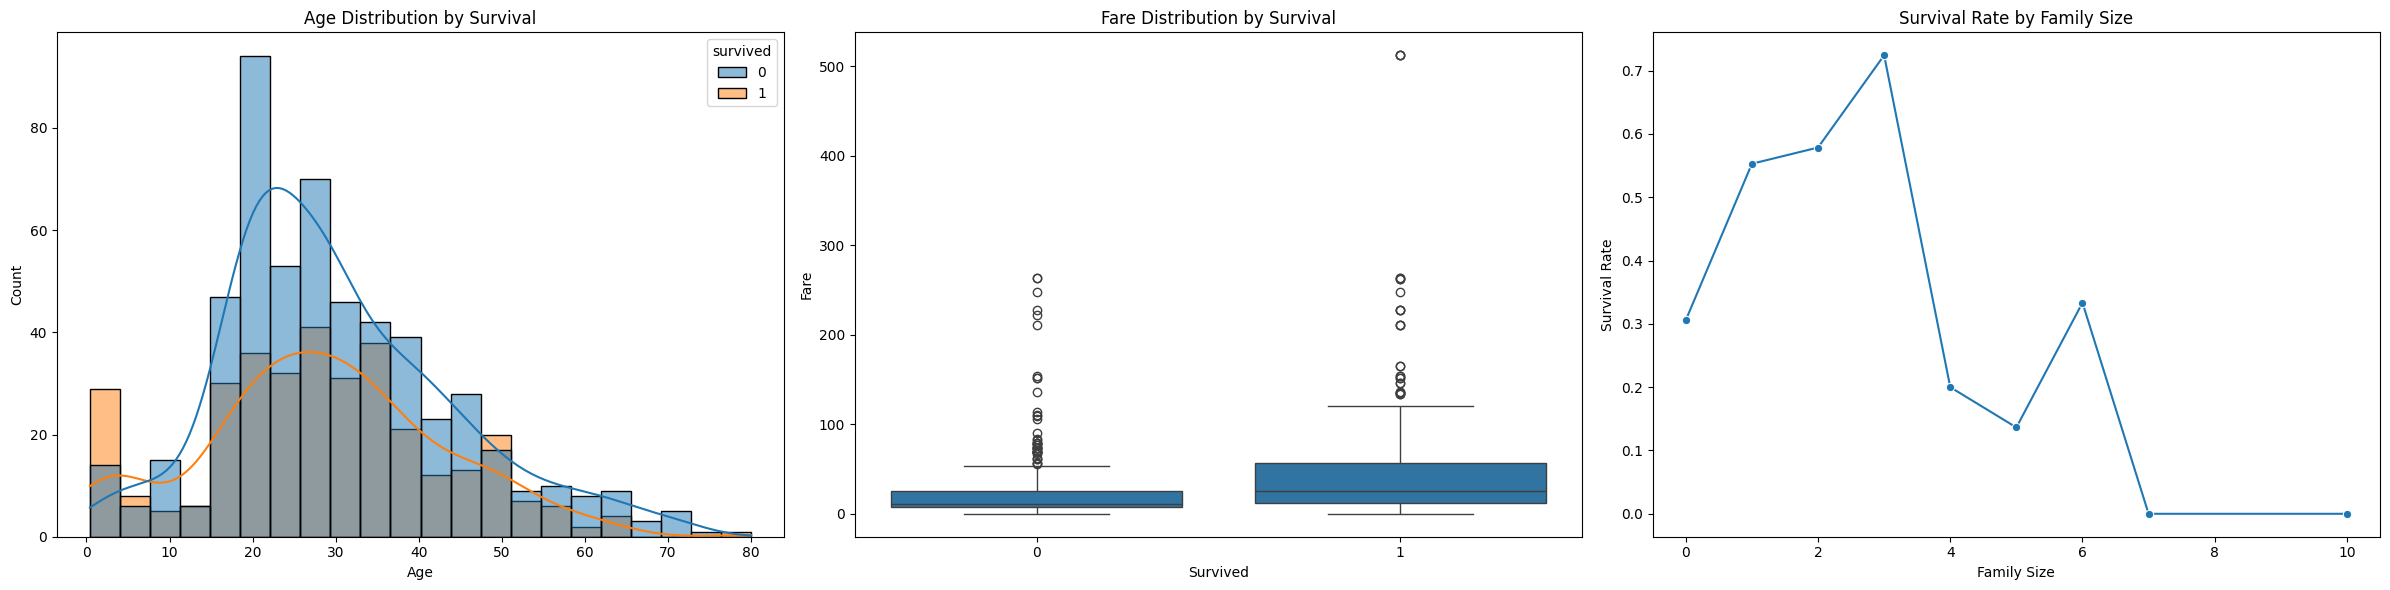

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# 1. Age distribution by survival
sns.histplot(
    data=data,
    x="age", 
    hue="survived", 
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Age Distribution by Survival")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# 2. Fare distribution/outliers
sns.boxplot(
    data=data, 
    x="survived", 
    y="fare",
    ax=axes[1]
)
axes[1].set_title("Fare Distribution by Survival")
axes[1].set_xlabel("Survived")
axes[1].set_ylabel("Fare")


# 3. Family size
eda_data = data.copy()
family_survival = (
    eda_data
    .groupby("family_size")["survived"]
    .agg(["count", "mean"])
    .reset_index()
)

sns.lineplot(
    data=family_survival,
    x="family_size",
    y="mean",
    marker="o",
    ax=axes[2]
)
axes[2].set_title("Survival Rate by Family Size")
axes[2].set_xlabel("Family Size")
axes[2].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

These plots show the relationship between individual features and survival.

The age distribution shows that age alone does not clearly separate survivors from non-survivors. Both groups contain many young and middle-aged passengers.

The fare boxplot shows that passengers who survived generally paid higher fares, although there are also strong outliers. This suggests that fare may be related to survival, possibly because it is connected to passenger class.

The family size plot shows that survival rate changes with family size. Very small or very large family groups may have different survival patterns, but some family size values have few samples, so the result should be interpreted carefully.

### 4.3 Correlation matrix

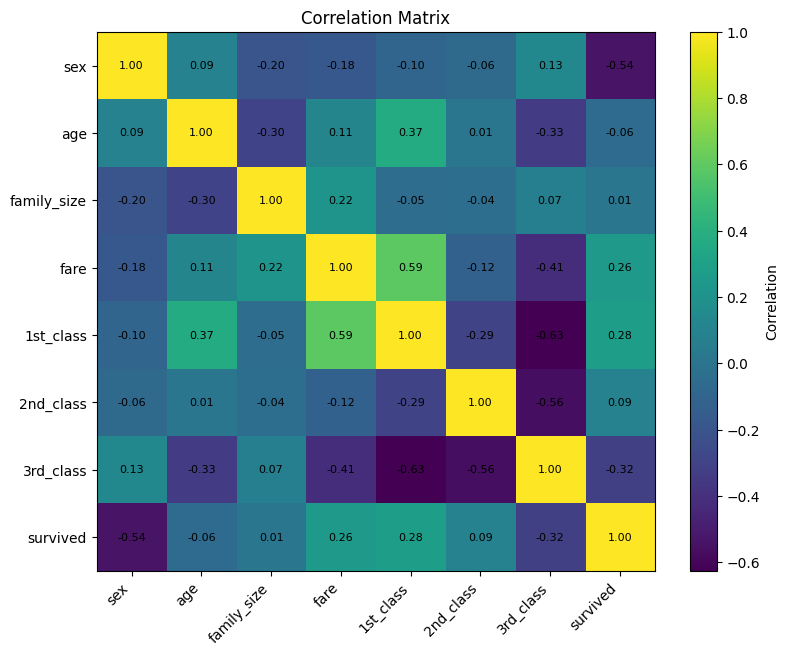

In [76]:
corr = data.corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )
plt.title("Correlation Matrix")
plt.show()

In [77]:
corr["survived"].sort_values(ascending=False)

survived       1.000000
1st_class      0.284495
fare           0.256179
2nd_class      0.091715
family_size    0.014673
age           -0.059665
3rd_class     -0.320134
sex           -0.542152
Name: survived, dtype: float64

The correlation heatmap shows that `sex` has a strong negative relationship with survival. This means that the encoded sex feature is one of the most important variables for predicting survival. Passenger class features are also related to survival: first class has a positive relationship with survival, while third class has a negative relationship.

### 4.4 Combined / relationship plots

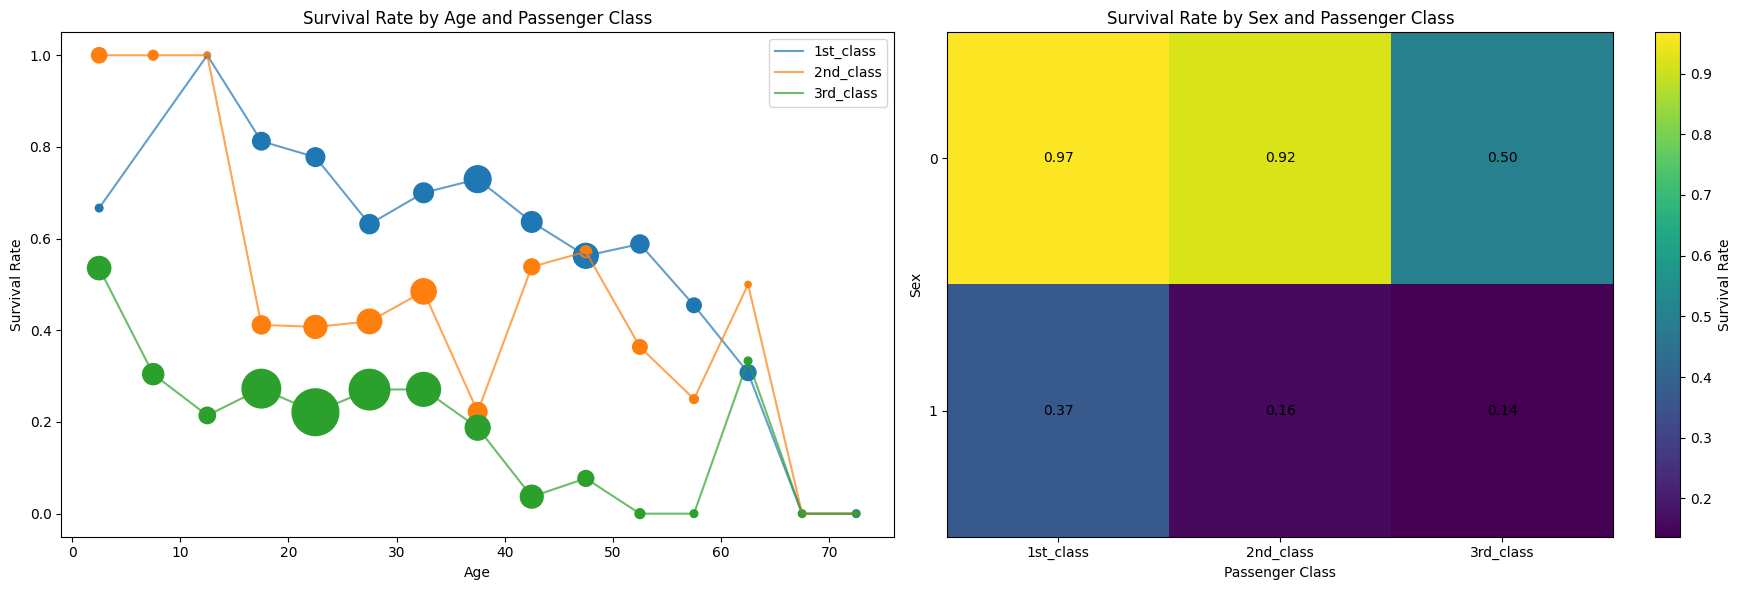

In [78]:
eda_data = data.copy()
eda_data["pclass"] = eda_data[["1st_class", "2nd_class", "3rd_class"]].idxmax(axis=1)

# eda_data.groupby("pclass")["survived"].mean() #Survival rate by class
eda_data["age_bin"] = pd.cut(
    eda_data["age"],
    bins=range(0, 85, 5),
    right=False
)

#map survival numbers with age
age_bin_class_survival = (
    eda_data
    .groupby(["age_bin", "pclass"], observed=False)["survived"]
    .agg(["count", "mean"])
    .reset_index()
)

age_bin_class_survival["age_mid"] = age_bin_class_survival["age_bin"].apply(
    lambda x: x.left + 2.5
)
sex_class_survival = eda_data.pivot_table(
    values="survived",
    index="sex",
    columns="pclass",
    aggfunc="mean"
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Survival rate by age and passenger class
for pclass in ["1st_class", "2nd_class", "3rd_class"]:
    subset = age_bin_class_survival[
        (age_bin_class_survival["pclass"] == pclass) &
        (age_bin_class_survival["count"] > 0)
    ].sort_values("age_mid")
    
    axes[0].plot(
        subset["age_mid"],
        subset["mean"],
        alpha=0.7,
        label=pclass
    )
    
    axes[0].scatter(
        subset["age_mid"],
        subset["mean"],
        s=subset["count"] * 10
    )

axes[0].set_xlabel("Age")
axes[0].set_ylabel("Survival Rate")
axes[0].set_title("Survival Rate by Age and Passenger Class")
axes[0].legend()


# 2. Survival rate by sex and passenger class
im = axes[1].imshow(sex_class_survival, aspect="auto")
fig.colorbar(im, ax=axes[1], label="Survival Rate")

axes[1].set_xticks(range(len(sex_class_survival.columns)))
axes[1].set_xticklabels(sex_class_survival.columns)

axes[1].set_yticks(range(len(sex_class_survival.index)))
axes[1].set_yticklabels(sex_class_survival.index)

for i in range(sex_class_survival.shape[0]):
    for j in range(sex_class_survival.shape[1]):
        value = sex_class_survival.iloc[i, j]
        axes[1].text(j, i, f"{value:.2f}", ha="center", va="center")

axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Sex")
axes[1].set_title("Survival Rate by Sex and Passenger Class")

plt.tight_layout()
plt.show()

These two plots show how survival is related to combinations of features.

The first plot shows survival rate by age group and passenger class. Age is grouped into 5-year bins to reduce the influence of extreme values from very small age samples. The size of each point represents the number of passengers in that age bin. Overall, passenger class appears to have a strong influence on survival, with first-class passengers generally having higher survival rates than third-class passengers.

The second plot shows survival rate by sex and passenger class. Female passengers had much higher survival rates than male passengers across all passenger classes. Passenger class also matters: first-class passengers generally had higher survival rates than third-class passengers. This suggests that both sex and passenger class are important predictors for the logistic regression model.

## 5. Model training and improvement
### 5.1 Define features and target

In [79]:
FEATURES = ["sex", "age", "family_size", "fare", "1st_class", "2nd_class", "3rd_class"]
TARGET = "survived"

features = data[FEATURES] ##take out the specific columns and make a new table
features.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class
0,1,22.0,1,7.2500,0,0,1
1,0,38.0,1,71.2833,1,0,0
2,0,26.0,0,7.9250,0,0,1
3,0,35.0,1,53.1000,1,0,0
4,1,35.0,0,8.0500,0,0,1


In [80]:
target = data[TARGET]
target.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

## 5.2 Prepare dataset
The dataset is split into a training set and a test set.<br>
The training set is used to train the model, while the test set is kept unseen and used later to evaluate the model.  

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
) 
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


`test_size=0.2` means 20% is used as the test set and 80% is used as the training set.<br>
`random_state=42` makes the split reproducible, so the same rows are selected each time the notebook is run.

## 5.3 Train Logistic Regression with scikit-learn

In [82]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000) #model init
model.fit(X_train, y_train) #model training

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [83]:
y_pred = model.predict(X_test) # let trained model to predict base on the features in test dataset
y_pred[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1])

In [84]:
y_proba = model.predict_proba(X_test)[:, 1]
print(y_proba) 

[0.32040285 0.17168984 0.02641529 0.25941956 0.12339733 0.69114681
 0.08421311 0.12396557 0.64310308 0.61552109 0.42405889 0.71898906
 0.49631655 0.04907053 0.48513262 0.21212148 0.04759193 0.91768787
 0.16037345 0.13739947 0.08383487 0.13004277 0.6765361  0.30278207
 0.28854644 0.37397328 0.16956501 0.18584866 0.08279484 0.48864436
 0.69081939 0.20916195 0.82922794 0.65150378 0.49954907 0.11645258
 0.08992088 0.41532994 0.87935505 0.77409978 0.13700115 0.02681343
 0.85461787 0.1319623  0.29274511 0.06039528 0.08320086 0.11267417
 0.08555764 0.09603029 0.03190812 0.07205125 0.1402358  0.07870982
 0.36316945 0.230534   0.33563912 0.11237693 0.92455437 0.1356804
 0.20033874 0.68325855 0.08993307 0.83412804 0.4445205  0.13256167
 0.12825955 0.7679881  0.09596203 0.34960552 0.13612229 0.95060315
 0.33172627 0.10914023 0.13618727 0.37265554 0.85755022 0.62759051
 0.68800741 0.12352308 0.26847658 0.09589753 0.22478297 0.1024357
 0.93661507 0.91651283 0.57007355 0.1024357  0.13612229 0.094494

## 6. Evaluate models

In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

### 6.1 Confusion matrix

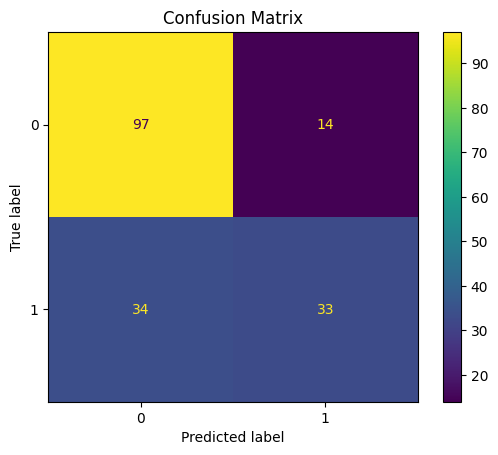

In [86]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

There are 97 true negatives and 33 true positives. It means 97 passengers were correctly predicted as not survived and 33 passengers were correctly predicted as survived.<br>

There are also 14 false positives and 34 false negatives, which means 14 passengers were predicted as survived but actually did not survive, and 34 passengers actually survived but were predicted as not survived.<br>

The model missed many actual survivors. Overall, the model performs better at identifying passengers who did not survive than passengers who survived.

### 6.2 Classification report

In [87]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.7303370786516854
Precision:  0.7021276595744681
Recall:  0.4925373134328358
F1 Score:  0.5789473684210527
              precision    recall  f1-score   support

           0       0.74      0.87      0.80       111
           1       0.70      0.49      0.58        67

    accuracy                           0.73       178
   macro avg       0.72      0.68      0.69       178
weighted avg       0.73      0.73      0.72       178



The model achieved an accuracy of about 73.03%, meaning that approximately 73% of the test data was predicted correctly.<br>
The precision is about 70.21%, so when the model predicts a passenger as survived, the prediction is correct about 70% of the time.<br>
The recall is only about 49.25%, which means Among the passengers who actually survived, only about 49% were correctly recognized by the model. It shows that the model missed about half of the actual survivors.<br>
The F1-score is about 57.89%. Since the recall is relatively low, the F1-score is also not very high. It means that the model is relatively careful when predicting survival, but it does not identify enough actual survivors.

### 6.7 ROC-AUC

In [88]:
y_proba_survived = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba_survived)
print("Classifier (AUC) = :", roc_auc)

Classifier (AUC) = : 0.8150463896732554


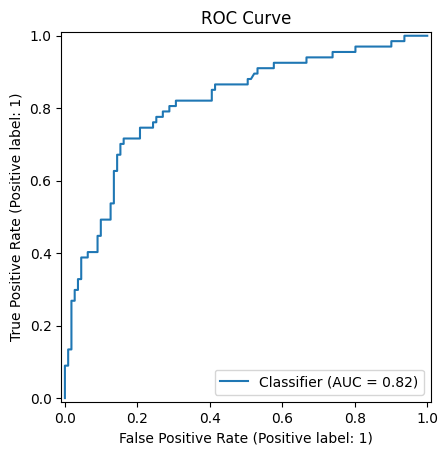

In [89]:
RocCurveDisplay.from_predictions(y_test, y_proba_survived)
plt.title("ROC Curve")
plt.show()

The ROC-AUC score shows that the model has a good ability to separate survived and not-survived passengers based on predicted probabilities. <br>
This means the probability ranking is useful, even though the default threshold of 0.5 gives a relatively low recall.

### 6.4 Model experiments

In [90]:
# stratified split data to keep same survived / not survived balance in train set and test set
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)
model_strat = LogisticRegression(max_iter=1000)
model_strat.fit(X_train_strat, y_train_strat)

y_pred_strat = model_strat.predict(X_test_strat)
y_proba_strat = model_strat.predict_proba(X_test_strat)[:, 1]
print(classification_report(y_test_strat, y_pred_strat))
print("ROC AUC:", roc_auc_score(y_test_strat, y_proba_strat))

              precision    recall  f1-score   support

           0       0.80      0.85      0.83       109
           1       0.74      0.67      0.70        69

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178

ROC AUC: 0.8510171519744714


In [91]:
# change threshold
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_strat >= threshold).astype(int)
    
    threshold_results.append({
        "model": f"Threshold={threshold}",
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_strat, y_pred_threshold),
        "precision": precision_score(y_test_strat, y_pred_threshold),
        "recall": recall_score(y_test_strat, y_pred_threshold),
        "f1_score": f1_score(y_test_strat, y_pred_threshold),
        "roc_auc": roc_auc_score(y_test_strat, y_proba_strat)
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,model,threshold,accuracy,precision,recall,f1_score,roc_auc
0,Threshold=0.3,0.3,0.735955,0.619565,0.826087,0.708075,0.851017
1,Threshold=0.4,0.4,0.792135,0.710526,0.782609,0.744828,0.851017
2,Threshold=0.5,0.5,0.780899,0.741935,0.666667,0.702290,0.851017
3,Threshold=0.6,0.6,0.775281,0.773585,0.594203,0.672131,0.851017
4,Threshold=0.7,0.7,0.775281,0.891892,0.478261,0.622642,0.851017


Changing the threshold does not change the predicted probabilities, so the ROC AUC remains the same. However, it changes the final class predictions, so accuracy, precision, recall, and F1-score change.

In [92]:
# balanced logistic regression model
model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
model_balanced.fit(X_train_strat, y_train_strat)

# X_train_strat, , y_train_strat, 
y_pred_balanced = model_balanced.predict(X_test_strat)
y_proba_balanced = model_balanced.predict_proba(X_test_strat)[:, 1]

print(classification_report(y_test_strat, y_pred_balanced))
print("ROC AUC:", roc_auc_score(y_test_strat, y_proba_balanced))

              precision    recall  f1-score   support

           0       0.85      0.80      0.82       109
           1       0.71      0.78      0.74        69

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.80      0.79      0.79       178

ROC AUC: 0.8476931259141072


In [93]:
# change c_value
C_values = [0.01, 0.1, 1, 10, 100]
c_results = []

for C in C_values:
    model_c = LogisticRegression(max_iter=1000, C=C)
    model_c.fit(X_train_strat, y_train_strat)
    
    y_pred_c = model_c.predict(X_test_strat)
    y_proba_c = model_c.predict_proba(X_test_strat)[:, 1]
    
    c_results.append({
        "model": f"C={C}",
        "C": C,
        "accuracy": accuracy_score(y_test_strat, y_pred_c),
        "precision": precision_score(y_test_strat, y_pred_c),
        "recall": recall_score(y_test_strat, y_pred_c),
        "f1_score": f1_score(y_test_strat, y_pred_c),
        "roc_auc": roc_auc_score(y_test_strat, y_proba_c)
    })

c_results_df = pd.DataFrame(c_results)
c_results_df

,model,C,accuracy,precision,recall,f1_score,roc_auc
0,C=0.01,0.01,0.679775,0.687500,0.318841,0.435644,0.800093
1,C=0.1,0.10,0.775281,0.745763,0.637681,0.687500,0.837455
2,C=1,1.00,0.780899,0.741935,0.666667,0.702290,0.851017
3,C=10,10.00,0.769663,0.718750,0.666667,0.691729,0.851549
4,C=100,100.00,0.769663,0.718750,0.666667,0.691729,0.851549


## 7. Conclusion

In this notebook, I used Logistic Regression to predict whether a passenger survived the Titanic disaster. This is a binary classification task, where the target variable is `survived`.

The dataset has no missing values, and about 38.6% of the passengers survived. Since the survived and not-survived classes are not perfectly balanced, I evaluated the model using several metrics instead of accuracy alone.

The baseline Logistic Regression model showed moderate performance. Its accuracy and precision were acceptable, but the recall was relatively low. This means that the model was relatively reliable when it predicted survival, but it missed many passengers who actually survived. The confusion matrix confirmed this weakness.

The ROC AUC score showed that the model had a good ability to distinguish between survived and not-survived passengers based on predicted probabilities. This means that the model ranked passengers reasonably well by survival probability, even though the default threshold of 0.5 produced a low recall.

I also tested several model improvements, including a stratified train-test split, different decision thresholds, `class_weight="balanced"`, and different values of the regularization parameter `C`. These experiments showed the trade-off between precision and recall. For example, lowering the threshold or using class weights can improve recall, but it may also reduce precision.

Overall, Logistic Regression is a good and interpretable baseline model for this task. However, its main limitation is the low recall for the survived class. A possible next step would be to choose a threshold based on the goal of the task or compare Logistic Regression with other classification models.